<a href="https://colab.research.google.com/github/Astronom2617/rossmann-sales-forecasting/blob/main/rossmann_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rossmann Store Sales — EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train = pd.read_csv('/content/drive/MyDrive/rossmann/train.csv',
                    parse_dates=['Date'], low_memory=False)
store = pd.read_csv('/content/drive/MyDrive/rossmann/store.csv')
test = pd.read_csv('/content/drive/MyDrive/rossmann/test.csv',
                   parse_dates=['Date'])

print('Train shape:', train.shape)
print('Store shape:', store.shape)
print('Test shape:', test.shape)

train.head(25)

Train shape: (1017209, 9)
Store shape: (1115, 10)
Test shape: (41088, 8)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [2]:
train.info()
train.isnull().sum()
store.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


In [3]:
train.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


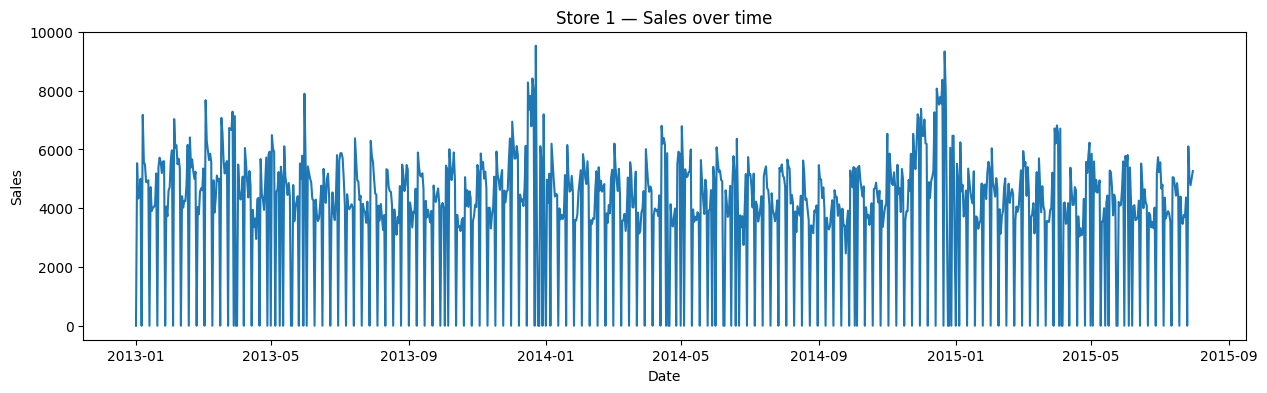

In [4]:
store_1 = train[train['Store'] == 1].sort_values('Date')

plt.figure(figsize=(15, 4))
plt.plot(store_1['Date'], store_1['Sales'])
plt.title('Store 1 — Sales over time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# 1. Conclusion about Store 1 (Sales over time)
There is definitely **seasonality**. At a minimum, we see **January 2014 and January 2015.**

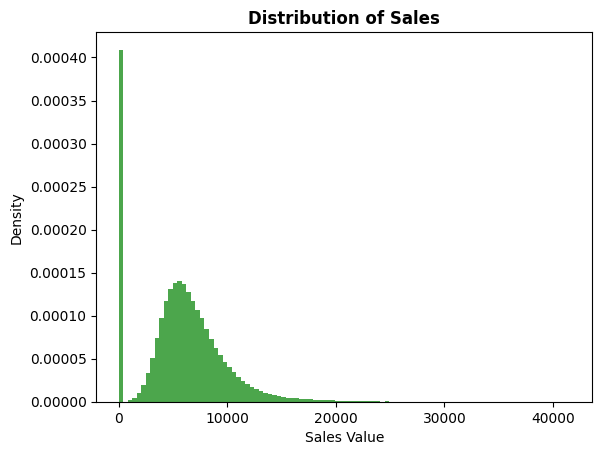

In [5]:
sales = train['Sales']
num_bins = 100
n, bins, _ = plt.hist(sales, num_bins, density=True, color='green', alpha=0.7)

plt.xlabel('Sales Value')
plt.ylabel('Density')
plt.title('Distribution of Sales', fontweight='bold')
plt.show()

# 2. Conclusion about Distribution of Sales
We see that there is an anomalous value at zero, but this happens because on some days when the store was closed, sales were equal to 0, which is normal.

In [6]:
avg_sales_by_day = train.groupby('DayOfWeek')['Sales'].mean()
avg_sales_by_day

dict_for_days = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

best_day_by_sales = avg_sales_by_day.idxmax()
amount_of_best_sales_day = avg_sales_by_day[best_day_by_sales]

print(f"Best sales day: {dict_for_days[best_day_by_sales]}")
print(f"Amount of Sales on {dict_for_days[best_day_by_sales]} is {amount_of_best_sales_day:.2f}")
print(avg_sales_by_day)

Best sales day: Monday
Amount of Sales on Monday is 7809.04
DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64


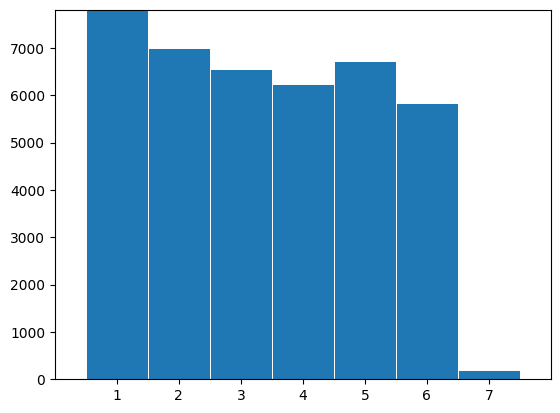

In [7]:
fig, ax = plt.subplots()

ax.bar(avg_sales_by_day.index, avg_sales_by_day.values,
       width=1, edgecolor="white", linewidth=0.7)

ax.set(
    xlim=(0, 8),
    xticks=np.arange(1, 8),
    ylim=(0, avg_sales_by_day.values.max()),
    yticks=np.arange(0, int(avg_sales_by_day.values.max()), 1000)
)

plt.show()

# 3. Conclusion about average sales by day of the week
As we can see, revenue is highest on Monday and lowest on Sunday. This is because, by law, everything is closed in Germany on Sundays, so revenue is either nonexistent or minimal in rare cases. On Monday, however, revenue is higher on average for an unknown reason. However, one possible reason is that all pharmacies open on Monday after being completely closed on Sunday, which could explain why a lot of people spend money on Monday, what means more average amount of sales.

In [8]:
sales_promo = train.groupby('Promo')['Sales'].mean()
sales_promo

,Sales
Promo,
0,4406.050805
1,7991.152046


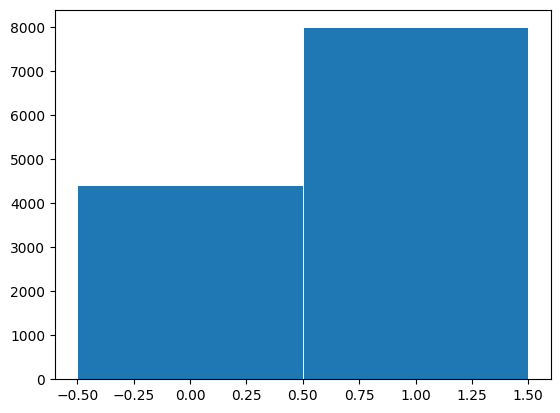

In [9]:
fig, ax = plt.subplots()

ax.bar(sales_promo.index, sales_promo.values,
       width=1, edgecolor="white", linewidth=0.7)

plt.show()

# 4. Conclusion about how Promo affect on Sales
As we see, on days with promotions, sales are significantly higher (average sales with promo: ~€7991 vs without: ~€4406, almost 2x difference) than on days without promotions. This suggests that, although various promotions are in effect, which could likely mean some loss (after all, prices could be lowered due to promotions), the exact opposite is true. There's a promotion -> more people because of it -> more sales -> more revenue.

In [10]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [11]:
train_store = train.merge(store, on='Store')
train_store.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [12]:
sales_by_store_type = train_store.groupby('StoreType')['Sales'].mean()
sales_by_store_type

,Sales
StoreType,
a,5738.179710
b,10058.837334
c,5723.629246
d,5641.819243


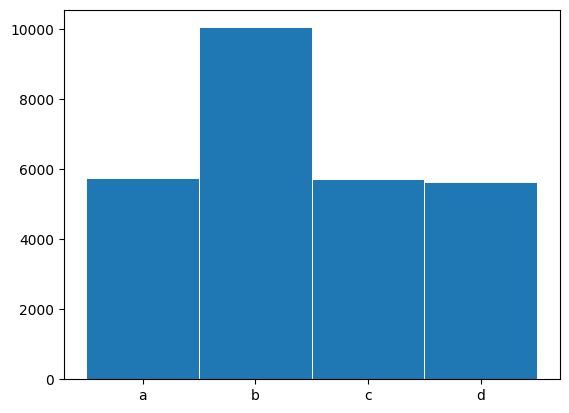

In [13]:
fig, ax = plt.subplots()

ax.bar(sales_by_store_type.index, sales_by_store_type.values,
       width=1, edgecolor="white", linewidth=0.7)

plt.show()

# 4. Conclusion about how StoreType affect on Sales
Stores with Type B have the greatest impact on sales compared to others (Type B -> €10,058, Types A, C, D -> €5,700 on average). This is likely due to a number of factors: more frequent promotions, more convenient locations, flexible opening hours, and a larger or more varied product range.

## EDA Summary
1. **Our data exhibits seasonality, which must be taken into account when forecasting**.


2. **Sales distribution is right-skewed. Zero values correspond to closed stores (Open=0) and will be filtered out before modeling. Note: Sunday sales are near-zero due to German law requiring stores to close — this is expected, not an anomaly.**


3. **On average, sales are highest on Monday (€7,809), and lowest on Sunday(€204), due to the German law.**

4. **Promotions have a significant impact on sales, as much as twice as much (average sales with promotions: ~€7,991 vs. without: ~€4,406), which is an important indicator for predicting sales.**

5. **Of all store types, B has the greatest impact on sales on average (Type B -> €10,058, Types A, C, D -> €5,700 on average).**